## Data Exploration

An important activity in data science is **exploratory data analysis (EDA)**. With EDA, we look at summary statistics of the data and use visualizations to understand the data we have. With EDA, your goal is to better understand you dataset features/columns and the relationships between them.  In addition to inspecting data (like we did for wrangling), we also do univariate, bivariate, and multivariate analysis. This helps us better understand the data before attempting to build models. 

Suppose you have the following data. What might EDA reveal?

In [6]:
import pandas as pd

df = pd.DataFrame({
    "Student": ["A", "B", "C"],
    "Hours Studied": [5, 10, 2],
    "Attendance": [90, 98, 70],
    "Exam Score": [82, 94, 65]
})

df

,Student,Hours Studied,Attendance,Exam Score
0,A,5,90,82
1,B,10,98,94
2,C,2,70,65


Understanding the data will help us understand what cleaning and transformations are needed and help us determine what machine learning models might work best.

We've already looked at basic statistical functions. Let's exploration visualizations in more detail.

In [8]:
# we need our imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # for searborn later

## One Feature

What kind of chart is often used to visualize one feature?
* categorical - count of categories - bar chart
* categorical proportion of feature relative to data set - proportion of data set - bar chart
* numerical features - histogram, density plot, box plot

Let's use the iris dataset for our exploration. This is a popular dataset use by individuals studying machine learning.

About the dataset: [https://archive.ics.uci.edu/dataset/53/iris](https://archive.ics.uci.edu/dataset/53/iris)

### Seaborn

Seaborn is a popular Python virtualization library that is based on matplotlib. It can create more amazing visuals than matplotlib alone. It provides you the ability to do more than what matplotlib alone permits, often with less coding. 

See [https://seaborn.pydata.org/](https://seaborn.pydata.org/)


In [10]:
# let's pull in some data
irisDf = sns.load_dataset("iris")

In [12]:
irisDf.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


First let's explore the kind of cool thinks seaborn can quickly do. These examples involve multiple features and offer opportunities for some quick analysis.

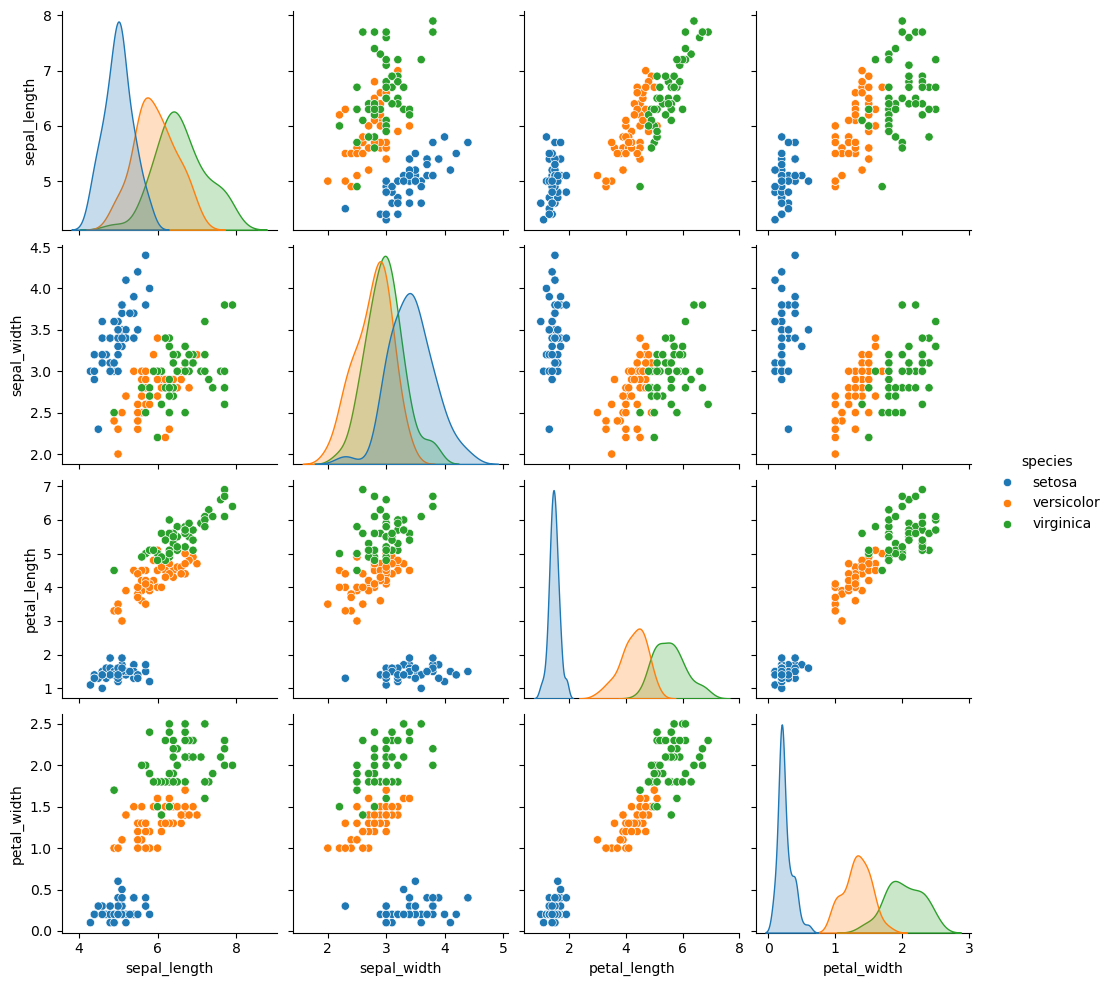

In [14]:
# plot pairwise relationships in a dataset
sns.pairplot(irisDf, hue='species', height=2.5)

Text(0.5, 1.0, 'Heatmap of Iris Features')

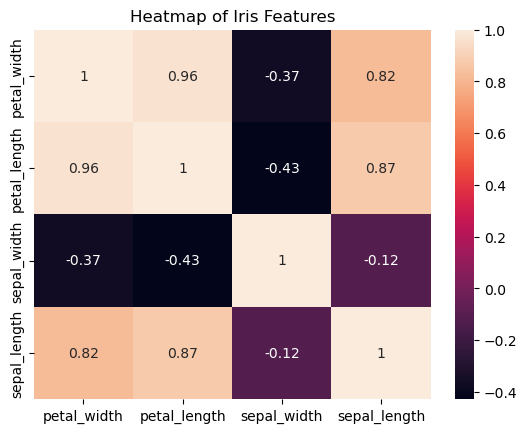

In [16]:
# to explore correlation of features
new_df = irisDf[['petal_width', 'petal_length', 'sepal_width', 'sepal_length']]
sns.heatmap(new_df.corr(), annot=True) # note the call to corr()
plt.title("Heatmap of Iris Features")

But back to one feature...

Text(0.5, 1.0, 'Simple Bar Chart')

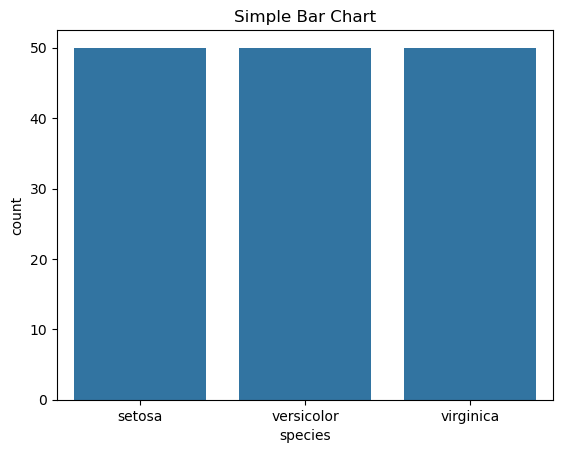

In [18]:
# simple bar chart
sns.countplot(irisDf, x='species')
plt.title("Simple Bar Chart")

Text(0.5, 1.0, 'Simple Bar Chart')

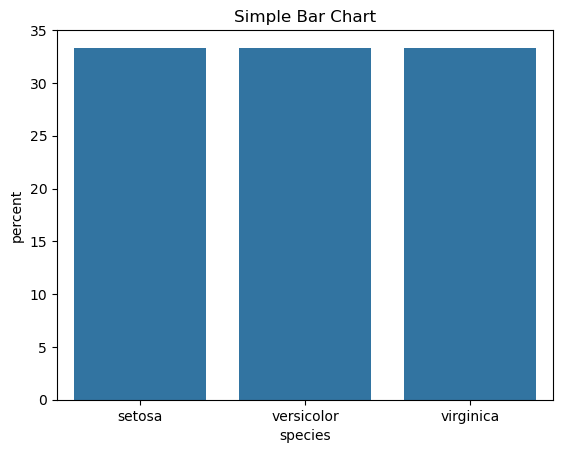

In [20]:
# simple bar chart that provides proportions
sns.countplot(irisDf, x='species', stat="percent") 
plt.title("Simple Bar Chart")

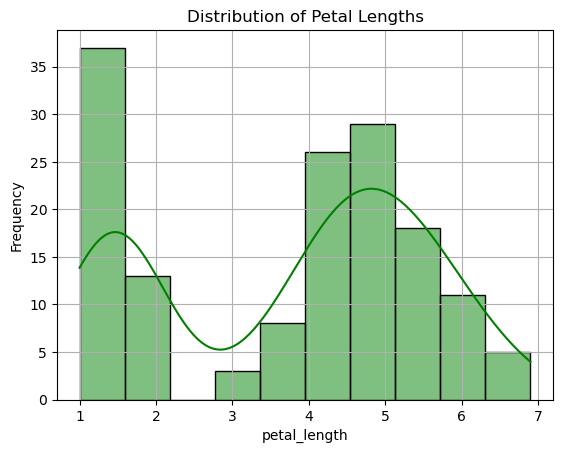

In [22]:
# simple histogram
# note kde (kernel density estimate) parameter provides smooth estimate of data distribution
sns.histplot(data=irisDf, x='petal_length', bins=10, color="green", kde=True)
plt.ylabel("Frequency")
plt.title("Distribution of Petal Lengths")
plt.grid(True)

What kind of chart is often used to visualize **multiple features**?
* scatter plot (can use both categorical and numerical)
* stacked bar or group bar chart (for visualizing two categorical features)

Text(0.5, 1.0, 'Scatter Plot')

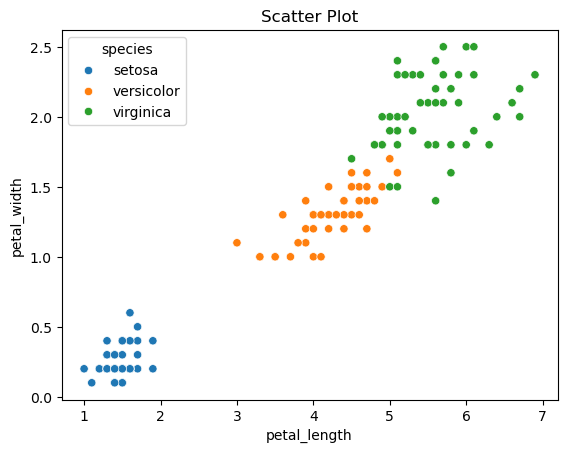

In [26]:
# scatter plot
sns.scatterplot(irisDf, x="petal_length", y="petal_width", hue='species')
plt.title('Scatter Plot')

Text(0.5, 1.0, 'Stacked Histogram')

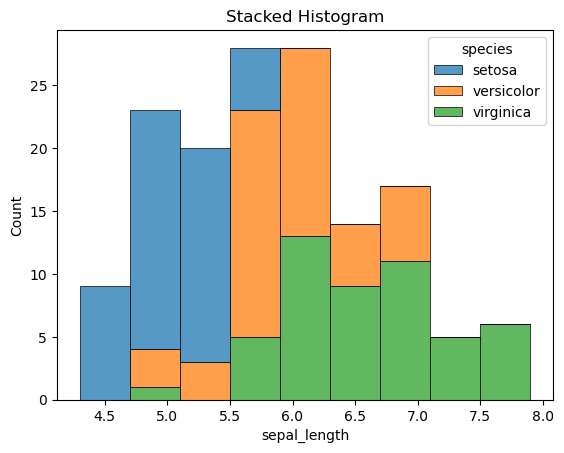

In [28]:
# stacked Histogram
sns.histplot(irisDf, x='sepal_length', hue='species', multiple='stack',
             linewidth=0.5)
plt.title('Stacked Histogram')


## About Multiple Features

Two categorical features:
* stacked bar chart
* grouped bar chart

Categorical and numerical features:
* strip plot
* swarm plot
* density plot
* violin plot [https://mode.com/blog/violin-plot-examples](https://mode.com/blog/violin-plot-examples)
* box plots

When showing more than two features, there are different techniques to use.

For numerical, options to show more than 2 include:
* color
* size
* transparency
* animation

For categorical, options to show more than 2 include:
* color
* shading
* size
* transparency
* shape
* faceting - multiple plots side by side


<Axes: xlabel='species', ylabel='petal_length'>

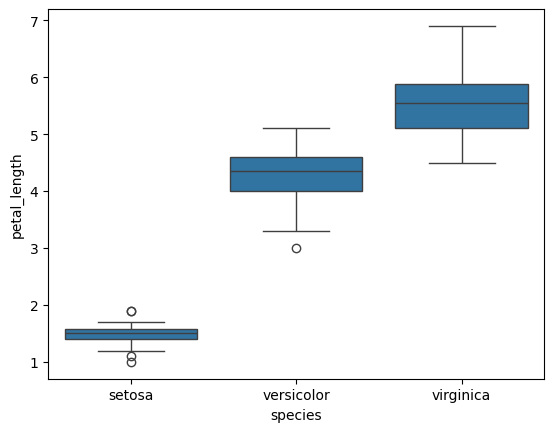

In [30]:
# box plot
sns.boxplot(irisDf, x="species", y="petal_length")

<Axes: xlabel='species', ylabel='petal_length'>

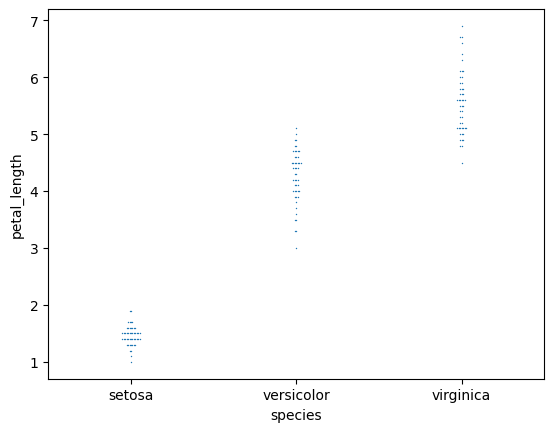

In [40]:
# Swarm plot
# shows distribution of a variable
# does not allow points to overlap significantly
sns.swarmplot(irisDf, x="species", y="petal_length", size=1)

<Axes: xlabel='species', ylabel='petal_length'>

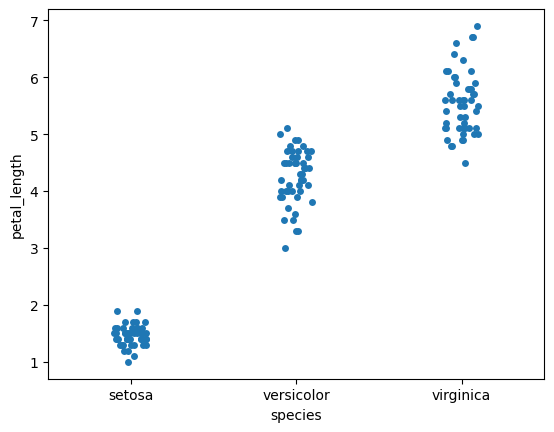

In [42]:
# Strip plot
# shows distribution of a variable
# does allow points to overlap/uses jittering
sns.stripplot(irisDf, x="species", y="petal_length")

<Axes: xlabel='species', ylabel='petal_length'>

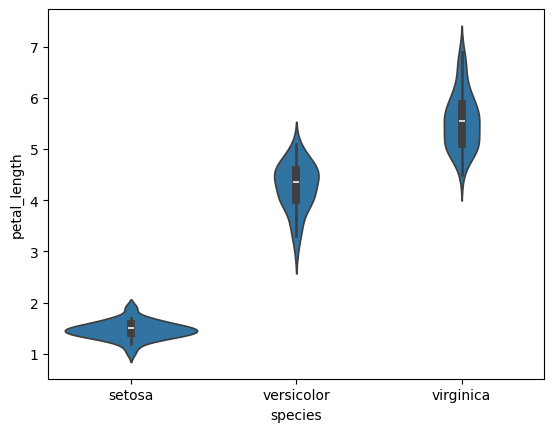

In [44]:
# Violin plot
# hybrid of box plot and kernel density plot
sns.violinplot(irisDf, x="species", y="petal_length")

<Axes: xlabel='petal_length', ylabel='Density'>

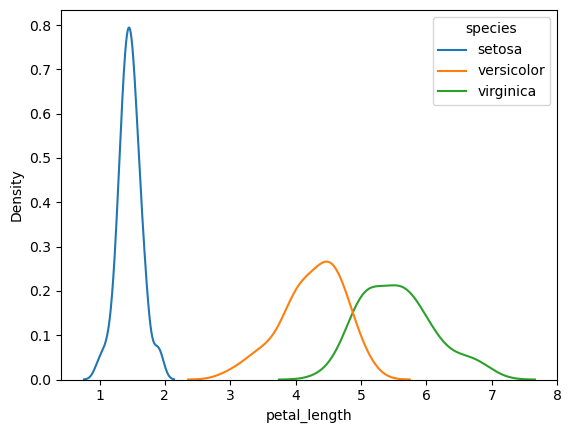

In [46]:
# Density plot 
sns.kdeplot(irisDf, x="petal_length", hue="species")

### Now, let's try more than two features
Reminder: For numerical,options to show more than 2 include:
* color (hue)
* size
* transparency
* animation

<Axes: xlabel='species', ylabel='petal_length'>

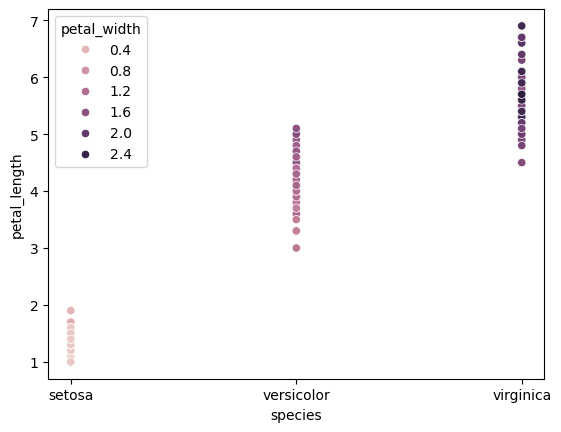

In [48]:
# with 3rd feature (petal_width)
sns.scatterplot(irisDf, x="species", y="petal_length", hue="petal_width")

<Axes: xlabel='species', ylabel='petal_length'>

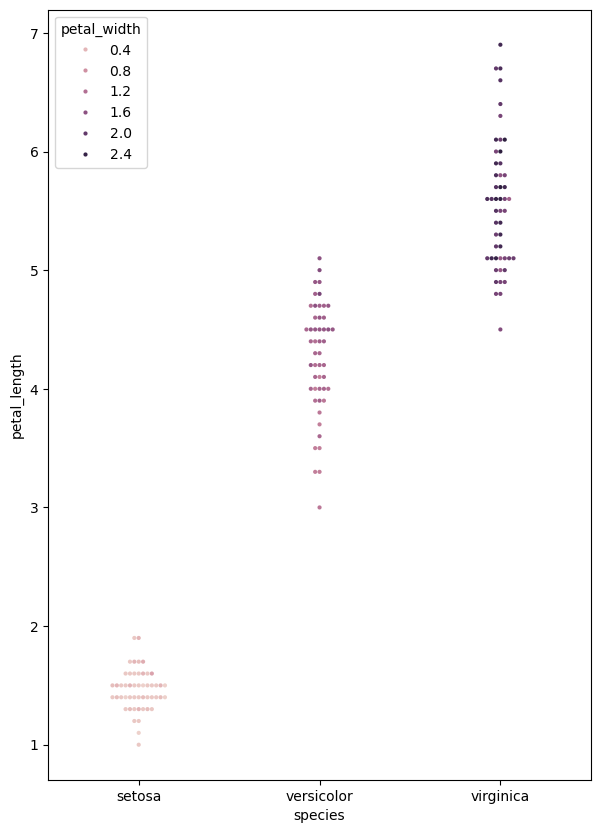

In [50]:
# with 3rd feature (petal_width)
plt.figure(figsize=(7, 10))
sns.swarmplot(irisDf, x="species", y="petal_length", hue="petal_width", size=3)

<Axes: xlabel='species', ylabel='petal_length'>

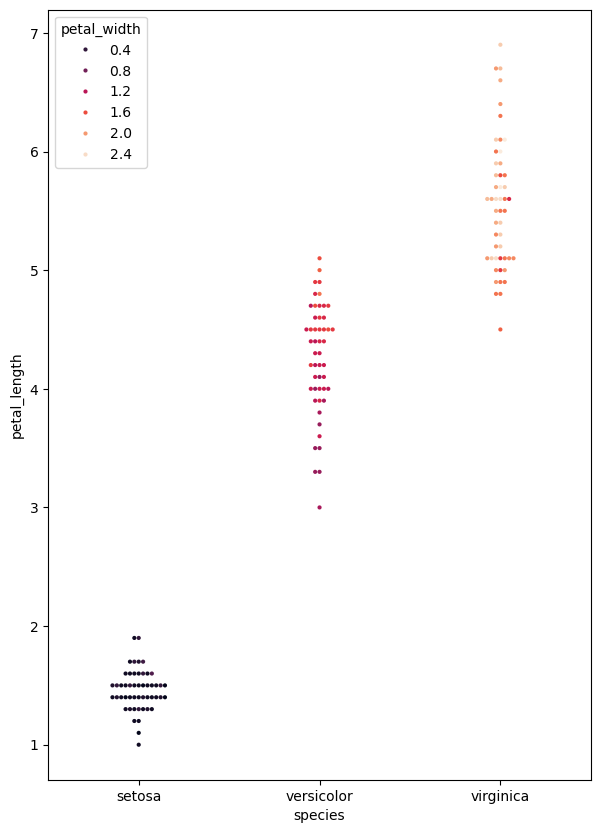

In [52]:
# see https://seaborn.pydata.org/tutorial/color_palettes.html
plt.figure(figsize=(7, 10))
sns.swarmplot(irisDf, x="species", y="petal_length", hue="petal_width", size=3, palette="rocket")

<Axes: xlabel='species', ylabel='petal_length'>

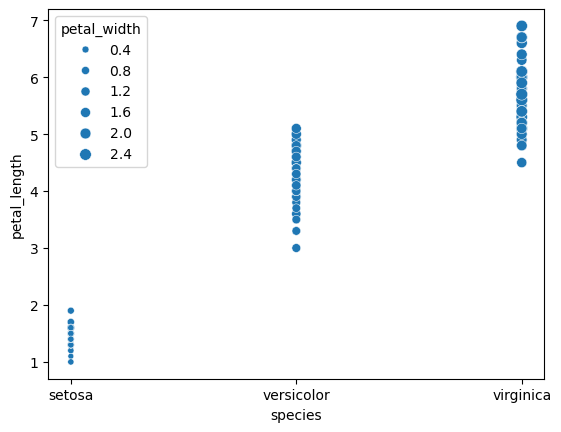

In [54]:
# Strip plot
# with 3rd feature (petal_width)
sns.scatterplot(irisDf, x="species", y="petal_length", size="petal_width")

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

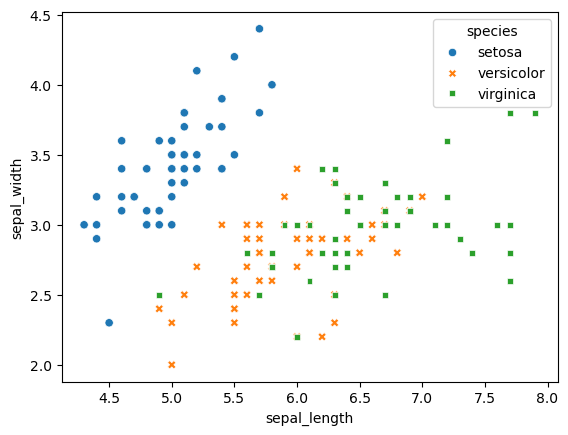

In [56]:
# with different shapes (markers)
sns.scatterplot(irisDf, x="sepal_length", y="sepal_width", hue='species', style='species')

### You try!
Reminder: For categorical, options to show more than 2 include:
* color
* shading
* size
* transparency
* shape
* faceting - multiple plots side by side

We'll use the tips dataset to explore this. This dataset shows restaurant tipping behavior.

In [58]:
# Let's bring in some new data with more categories
tips = sns.load_dataset("tips")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


1. Create a pairplot that shows features of this dataset and uses the "sex" feature for shading of data points. 

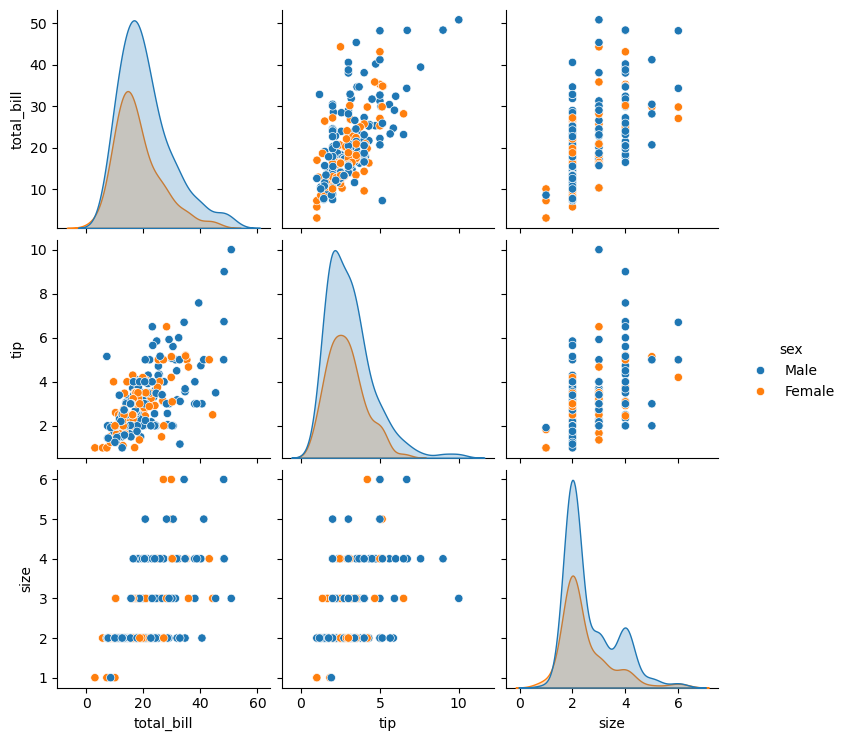

In [62]:
sns.pairplot(tips, hue="sex")

2. Create a correlation/heatmap of the numerical features. 

<Axes: >

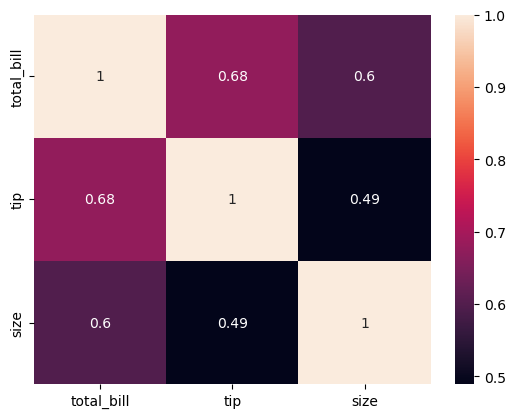

In [66]:
new_df = tips[["total_bill", "tip", "size"]]
sns.heatmap(new_df.corr(), annot=True)

3. Create a count plot that plot the day on the x axis.  Use different colors for different genders.  

<Axes: xlabel='day', ylabel='count'>

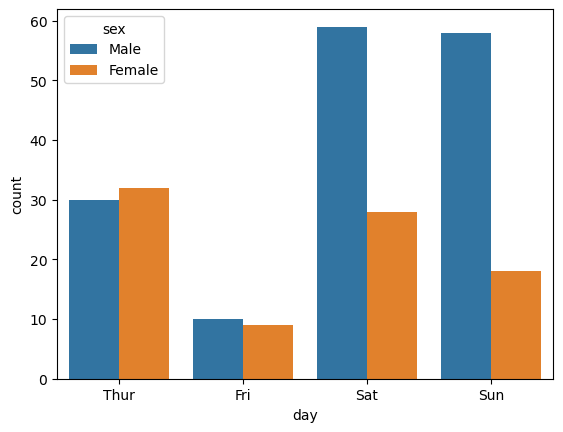

In [68]:
sns.countplot(tips, x="day", hue="sex")

4. Create a **bar** plot that plot the day on the x axis and the total bill on the y to compare these two features.  Use different colors for different genders.

<Axes: xlabel='day', ylabel='total_bill'>

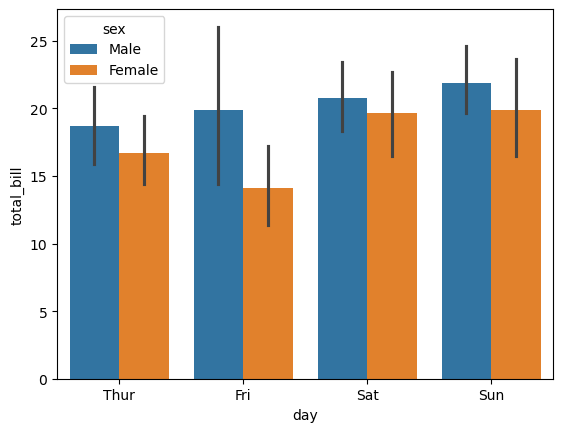

In [70]:
sns.barplot(tips, x="day", y="total_bill", hue="sex")

5. Create a swarm plot (a type of category plot) that shows day on the x axis and total bill on the y axis. Use gender for point colors.

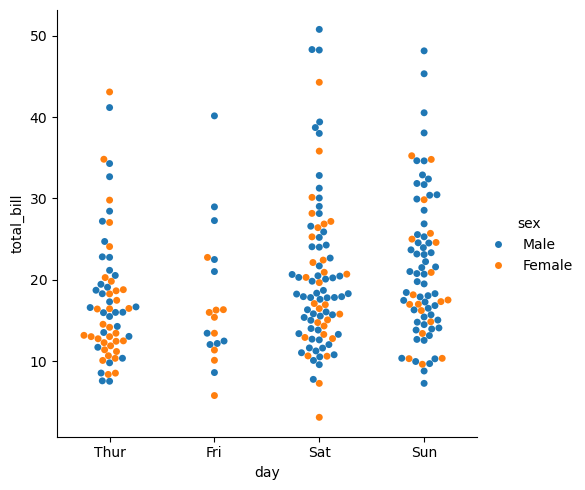

In [72]:
sns.catplot(tips, x="day", y="total_bill", hue="sex", kind="swarm")

6. Do the same as the above, but for the box plot (e.g. different kind). 

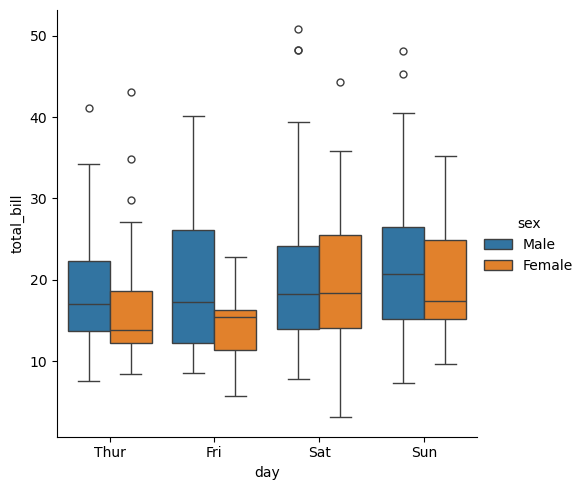

In [74]:
sns.catplot(tips, x="day", y="total_bill", hue="sex", kind="box")

Not: Seaborn does not have native support for animations.  Can use other libraries to assist with this. 
